In [ ]:
import torch 
from torch import nn 
from torch.optim import Adam 
import torchvision.transforms as transforms 
from torch.utils.data import Dataset, DataLoader 
from sklearn.preprocessing import LabelEncoder 
import matplotlib.pyplot as plt 
from PIL import Image 
import pandas as pd 
import numpy as np 
import os 

device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cuda


In [ ]:
labels=[]
image_path=[]
for i in os.listdir('/content/animal-faces/afhq'):
  for label in os.listdir(f'/content/animal-faces/afhq/{i}'):
    for image in os.listdir(f'/content/animal-faces/afhq/{i}/{label}'):
      labels.append(label) # Append/Put this label in the list
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")

data_df = pd.DataFrame(zip(image_path, labels), columns = ['image_paths', 'labels']) 
data_df.head() 


,image_paths,labels
0,/content/animal-faces/afhq/val/wild/flickr_wil...,wild
1,/content/animal-faces/afhq/val/wild/flickr_wil...,wild
2,/content/animal-faces/afhq/val/wild/flickr_wil...,wild
3,/content/animal-faces/afhq/val/wild/flickr_wil...,wild
4,/content/animal-faces/afhq/val/wild/flickr_wil...,wild


In [ ]:
train_df=data_df.sample(frac=0.7,random_state=200)
test_df=data_df.drop(train_df.index)

val=test_df.sample(frac=0.5,random_state=200)
test_df=test_df.drop(val.index)

In [ ]:
le=LabelEncoder()
le.fit(data_df['labels'])

transform=transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [ ]:
class ImageDataset(Dataset):
  def __init__(self, df, transform=None):
    self.df=df
    self.transform=transform
    self.labels=torch.tensor(le.transform(self.df['labels'])).to(device)

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    image_path=self.df.iloc[idx,0]
    label=self.labels[idx]
    image=Image.open(image_path).convert('RGB')
    if self.transform:
      image=self.transform(image).to(device)
    return image, label

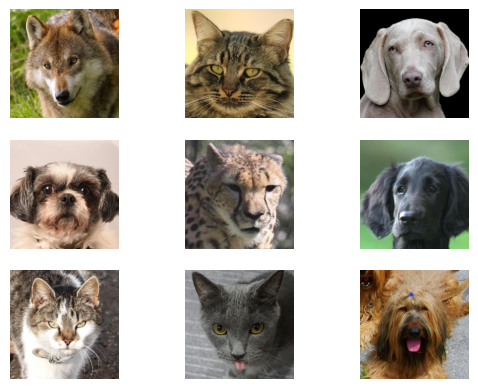

In [ ]:
n_rows = 3
n_cols = 3
f, axarr = plt.subplots(n_rows, n_cols)
for row in range(n_rows):
    for col in range(n_cols):
      image = Image.open(data_df.sample(n = 1)['image_paths'].iloc[0]).convert("RGB")
      axarr[row, col].imshow(image)
      axarr[row, col].axis('off')

plt.show()

In [ ]:
train_dataset = ImageDataset(train_df, transform=transform)
val_dataset = ImageDataset(val, transform=transform)
test_dataset = ImageDataset(test_df, transform=transform)

In [ ]:
train_dataloader=DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader=DataLoader(test_dataset, batch_size=32, shuffle=True)
val_dataloader=DataLoader(val_dataset, batch_size=32, shuffle=True)

In [ ]:
class CNNModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1=nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
    self.conv2=nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
    self.conv3=nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
    self.pooling=nn.MaxPool2d(kernel_size=2, stride=2)

    self.relu=nn.ReLU()
    self.flatten=nn.Flatten()
    self.linear=nn.Linear((128*16*16),128)
    self.output=nn.Linear(128,len(data_df['labels'].unique()))

  def forward(self, x):
      x = self.conv1(x) # -> Outputs: (32, 128, 128)
      x = self.pooling(x)# -> Outputs: (32, 64, 64)
      x = self.relu(x)
      x = self.conv2(x) # -> Outputs: (64, 64, 64)
      x = self.pooling(x) # -> Outputs: (64, 32, 32)
      x = self.relu(x)
      x = self.conv3(x) # -> Outputs: (128, 32, 32)
      x = self.pooling(x) # -> Outputs: (128, 16, 16)
      x = self.relu(x)
      x = self.flatten(x)
      x = self.linear(x)
      x = self.output(x)

      return x


model=CNNModel().to(device)



In [ ]:
criterion=nn.CrossEntropyLoss()
optimizer=Adam(model.parameters(), lr=0.001)

In [25]:
total_train_loss_plot=[]
total_train_acc_plot=[]
total_val_loss_plot=[]
total_val_acc_plot=[]

epochs=10

for epoch in range(epochs):
  total_train_loss=0
  total_train_acc=0
  total_val_loss=0
  total_val_acc=0
  model.train()
  for inputs,labels in train_dataloader:
    optimizer.zero_grad()
    output=model(inputs)
    train_loss=criterion(output,labels)
    total_train_loss=total_train_loss+train_loss.item()
    train_loss.backward()
    train_acc=(torch.argmax(output,axis=1)==labels).sum().item()
    total_train_acc+=train_acc
    optimizer.step()

  model.eval()
  with torch.no_grad():

    for inputs,labels in val_dataloader:
      output=model(inputs)
      val_loss=criterion(output,labels)
      total_val_loss+=val_loss.item()
      val_acc=(torch.argmax(output,axis=1)==labels).sum().item()
      total_val_acc+=val_acc

  total_train_loss_plot.append(round(total_train_loss/len(train_dataloader), 4))
  total_val_loss_plot.append(round(total_val_loss/len(val_dataloader), 4))
  total_train_acc_plot.append(round(total_train_acc/len(train_dataset) * 100, 4))
  total_val_acc_plot.append(round(total_val_acc/len(val_dataset) * 100, 4))


  print(f'''Epoch {epoch+1}/{epochs}, Train Loss: {round(total_train_loss/100, 4)} Train Accuracy {round((total_train_acc)/train_dataset.__len__() * 100, 4)}
              Validation Loss: {round(total_val_loss/100, 4)} Validation Accuracy: {round((total_val_acc)/val_dataset.__len__() * 100, 4)}''')
  print("="*30)



Epoch 1/10, Train Loss: 0.1252 Train Accuracy 98.7778
              Validation Loss: 0.1331 Validation Accuracy: 95.3719
Epoch 2/10, Train Loss: 0.0739 Train Accuracy 99.3358
              Validation Loss: 0.1063 Validation Accuracy: 96.6529
Epoch 3/10, Train Loss: 0.1138 Train Accuracy 98.9018
              Validation Loss: 0.1151 Validation Accuracy: 95.6612
Epoch 4/10, Train Loss: 0.0676 Train Accuracy 99.2295
              Validation Loss: 0.136 Validation Accuracy: 95.5372
Epoch 5/10, Train Loss: 0.0933 Train Accuracy 99.1321
              Validation Loss: 0.1331 Validation Accuracy: 96.0331
Epoch 6/10, Train Loss: 0.0523 Train Accuracy 99.4775
              Validation Loss: 0.2231 Validation Accuracy: 94.3388
Epoch 7/10, Train Loss: 0.0852 Train Accuracy 99.2649
              Validation Loss: 0.126 Validation Accuracy: 96.4876
Epoch 8/10, Train Loss: 0.0392 Train Accuracy 99.6457
              Validation Loss: 0.1379 Validation Accuracy: 96.4463
Epoch 9/10, Train Loss: 0.0123 Tra

In [27]:
with torch.no_grad():
  total_test_loss=0
  total_test_acc=0
  for input,label in test_dataloader:
    output=model(input)
    test_loss=criterion(output,label)
    test_acc=(torch.argmax(output,axis=1)==label).sum().item()
    total_test_loss+=test_loss.item()
    total_test_acc+=test_acc

print(f"Accuracy Score is: {round((total_test_acc/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_test_loss/1000, 4)}")



Accuracy Score is: 95.1633 and Loss is 0.0224


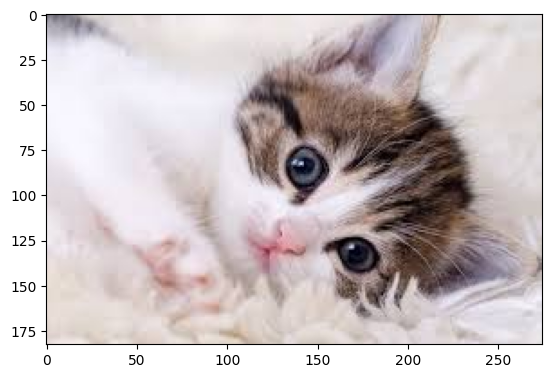


Prediction: 



array(['cat'], dtype=object)

In [29]:
def predict(image_path):
  image=Image.open(image_path).convert('RGB')
  image=transform(image).to(device)

  output=model(image.unsqueeze(0))
  output=torch.argmax(output,axis=1).item()
  return le.inverse_transform([output])


image_p=Image.open("/content/cat_image.jpeg")
plt.imshow(image_p)
plt.show()

print()
print("Prediction: \n")
predict("/content/cat_image.jpeg")



In [30]:
torch.save(model.state_dict(), 'animal_faces_model.pth')

In [31]:
import pickle

with open('label_enoder.pkl','wb') as f:
  pickle.dump(le,f)